In [ ]:
# Load the dataset
from google.colab import files
uploaded = files.upload()

Saving miami-housing.csv to miami-housing.csv


Output()

Output()

                         mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  \
beta_cntr_dist          0.004  0.007    -0.009      0.019        0.0      0.0   
beta_lnd_sqfoot         0.025  0.005     0.015      0.035        0.0      0.0   
beta_ocean_dist        -0.143  0.005    -0.153     -0.133        0.0      0.0   
beta_spec_feat_val      0.101  0.005     0.092      0.112        0.0      0.0   
beta_structure_quality  0.320  0.005     0.311      0.330        0.0      0.0   
beta_subcntr_di        -0.220  0.007    -0.234     -0.204        0.0      0.0   
beta_tot_lvg_area       0.578  0.005     0.567      0.589        0.0      0.0   
intercept               0.000  0.004    -0.008      0.009        0.0      0.0   
sigma                   0.511  0.003     0.505      0.517        0.0      0.0   

                        ess_bulk  ess_tail  r_hat  
beta_cntr_dist            4035.0    3250.0    1.0  
beta_lnd_sqfoot           4744.0    3095.0    1.0  
beta_ocean_dist           4781.0 

array([[<Axes: title={'center': 'beta_cntr_dist'}>,
        <Axes: title={'center': 'beta_lnd_sqfoot'}>,
        <Axes: title={'center': 'beta_ocean_dist'}>],
       [<Axes: title={'center': 'beta_spec_feat_val'}>,
        <Axes: title={'center': 'beta_structure_quality'}>,
        <Axes: title={'center': 'beta_subcntr_di'}>],
       [<Axes: title={'center': 'beta_tot_lvg_area'}>,
        <Axes: title={'center': 'intercept'}>,
        <Axes: title={'center': 'sigma'}>]], dtype=object)

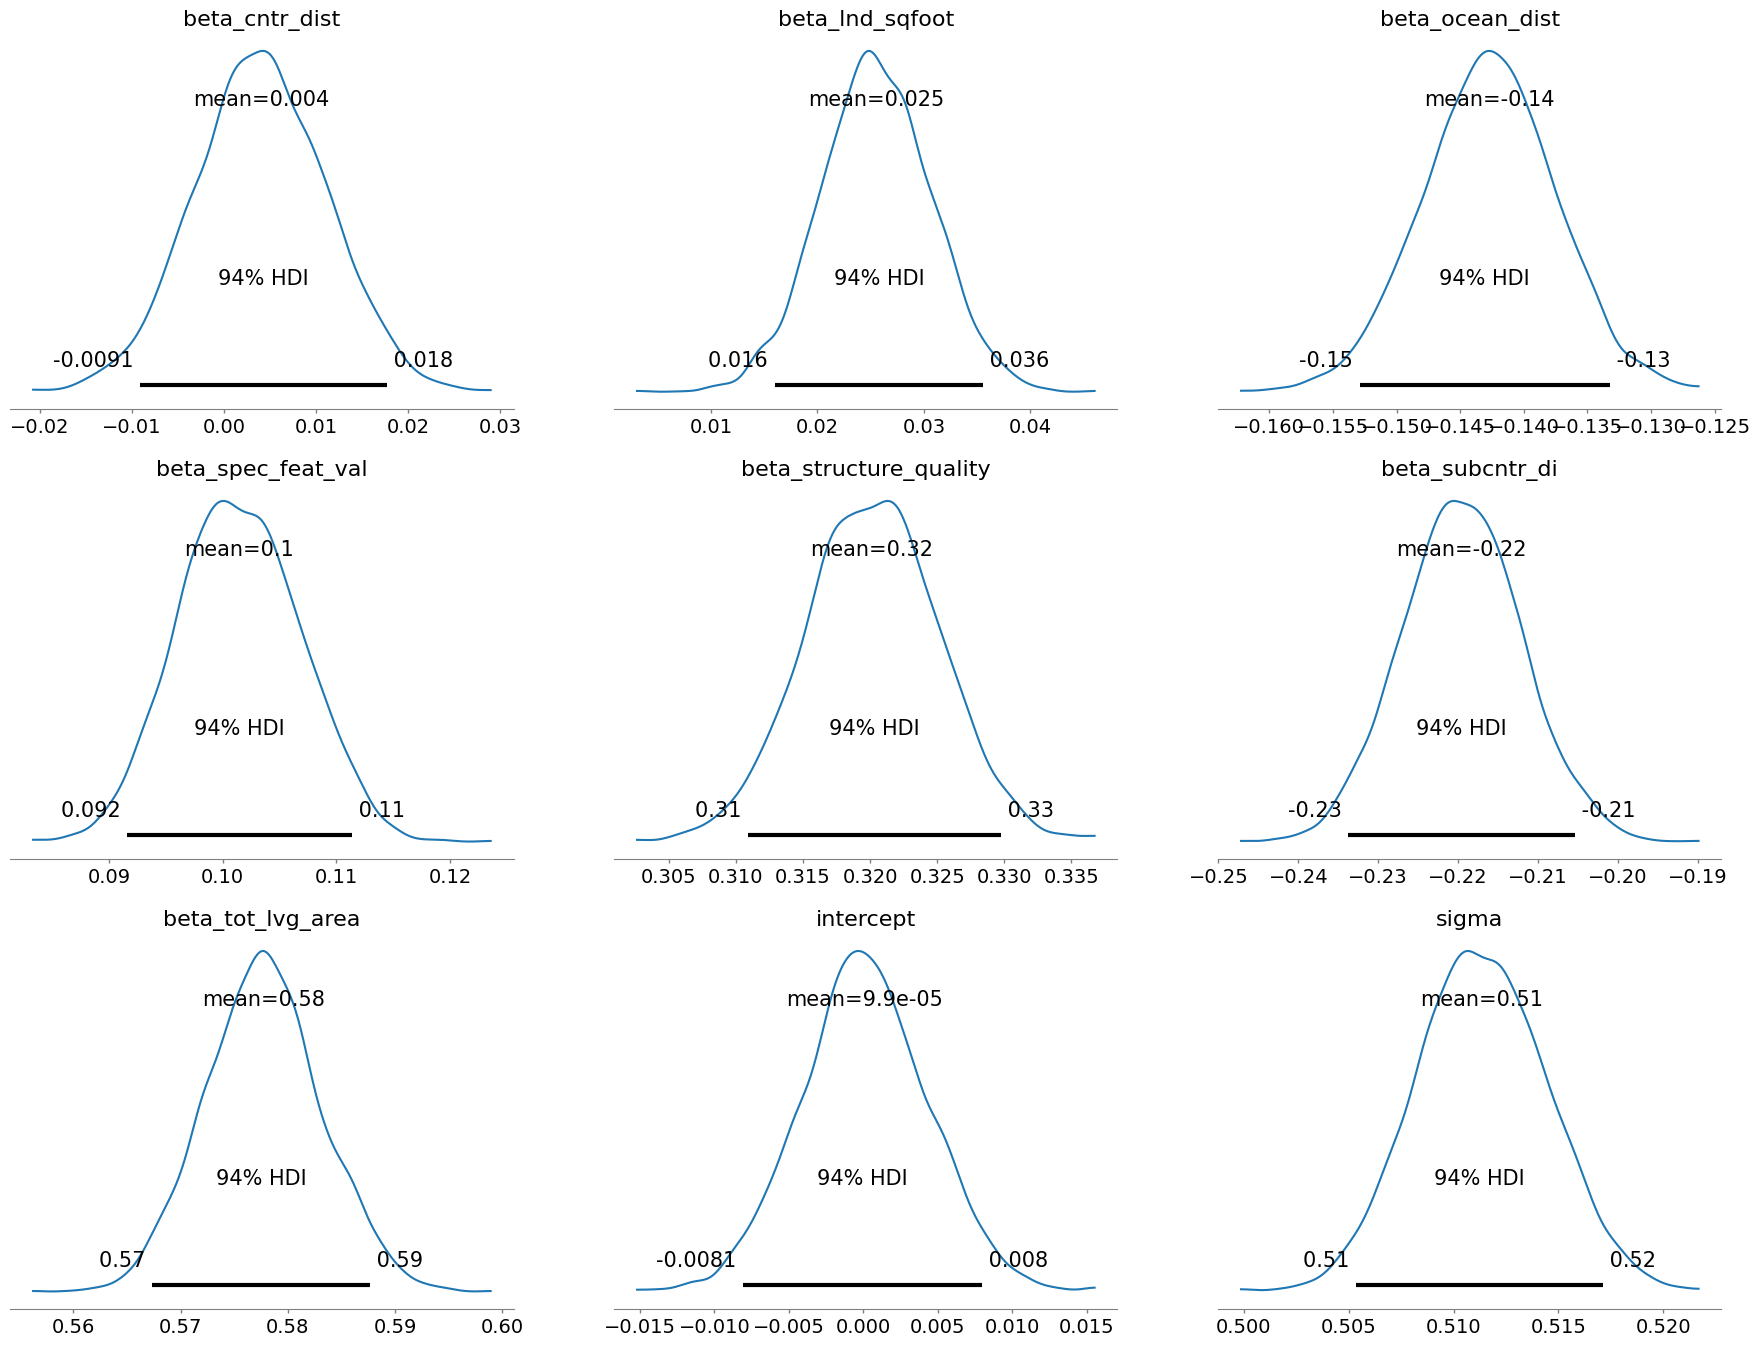

In [ ]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az

miami_housing_data = pd.read_csv('miami-housing.csv')

# Specify dependent and predictor variables
predictors = [
    "TOT_LVG_AREA",
    "SPEC_FEAT_VAL",
    "structure_quality",
    "LND_SQFOOT",
    "OCEAN_DIST",
    "SUBCNTR_DI",
    "CNTR_DIST",
]
dependent_variable = "SALE_PRC"

# Apply log transformation to skewed variables
log_transformed_data = miami_housing_data.copy()
log_transformed_data["SALE_PRC"] = np.log1p(log_transformed_data["SALE_PRC"])  # log1p to handle zeros gracefully
log_transformed_data["LND_SQFOOT"] = np.log1p(log_transformed_data["LND_SQFOOT"])

# Standardize predictors and dependent variable for Bayesian modeling
standardized_data = log_transformed_data.copy()
for col in predictors:
    standardized_data[col] = (standardized_data[col] - standardized_data[col].mean()) / standardized_data[col].std()
standardized_data[dependent_variable] = (
    standardized_data[dependent_variable] - standardized_data[dependent_variable].mean()
) / standardized_data[dependent_variable].std()

# Define Bayesian regression model
with pm.Model() as bayesian_model:
    # Priors for coefficients
    beta_tot_lvg_area = pm.Normal("beta_tot_lvg_area", mu=0.5, sigma=0.2)
    beta_spec_feat_val = pm.Normal("beta_spec_feat_val", mu=0.4, sigma=0.2)
    beta_structure_quality = pm.Normal("beta_structure_quality", mu=0.3, sigma=0.1)
    beta_lnd_sqfoot = pm.Normal("beta_lnd_sqfoot", mu=0.3, sigma=0.1)
    beta_ocean_dist = pm.Normal("beta_ocean_dist", mu=-0.2, sigma=0.1)
    beta_subcntr_di = pm.Normal("beta_subcntr_di", mu=-0.3, sigma=0.1)
    beta_cntr_dist = pm.Normal("beta_cntr_dist", mu=-0.2, sigma=0.1)

    # Intercept
    intercept = pm.Normal("intercept", mu=0, sigma=1)

    # Linear model
    mu = (
        intercept
        + beta_tot_lvg_area * standardized_data["TOT_LVG_AREA"]
        + beta_spec_feat_val * standardized_data["SPEC_FEAT_VAL"]
        + beta_structure_quality * standardized_data["structure_quality"]
        + beta_lnd_sqfoot * standardized_data["LND_SQFOOT"]
        + beta_ocean_dist * standardized_data["OCEAN_DIST"]
        + beta_subcntr_di * standardized_data["SUBCNTR_DI"]
        + beta_cntr_dist * standardized_data["CNTR_DIST"]
    )

    # Error term (likelihood)
    sigma = pm.HalfNormal("sigma", sigma=1)
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=standardized_data[dependent_variable])

    # Sampling from the posterior
    trace = pm.sample(2000, tune=1000, return_inferencedata=True, random_seed=42)

# Summarize results
summary = az.summary(trace, hdi_prob=0.95)
print(summary)

# Plot posterior distributions
az.plot_posterior(trace)


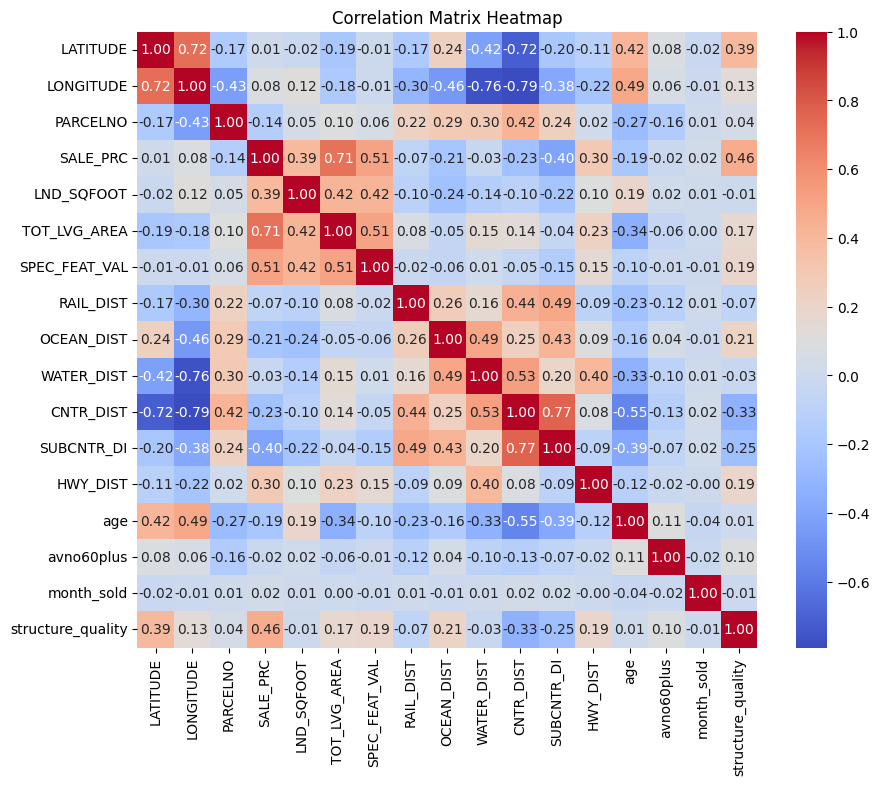

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset

miami_housing_data = pd.read_csv('miami-housing.csv')

# Log-transform skewed variables
log_transformed_data = miami_housing_data.copy()
log_transformed_data["SALE_PRC"] = np.log1p(log_transformed_data["SALE_PRC"])
log_transformed_data["LND_SQFOOT"] = np.log1p(log_transformed_data["LND_SQFOOT"])

# Correlation matrix
correlation_matrix = log_transformed_data.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix Heatmap")
plt.show()


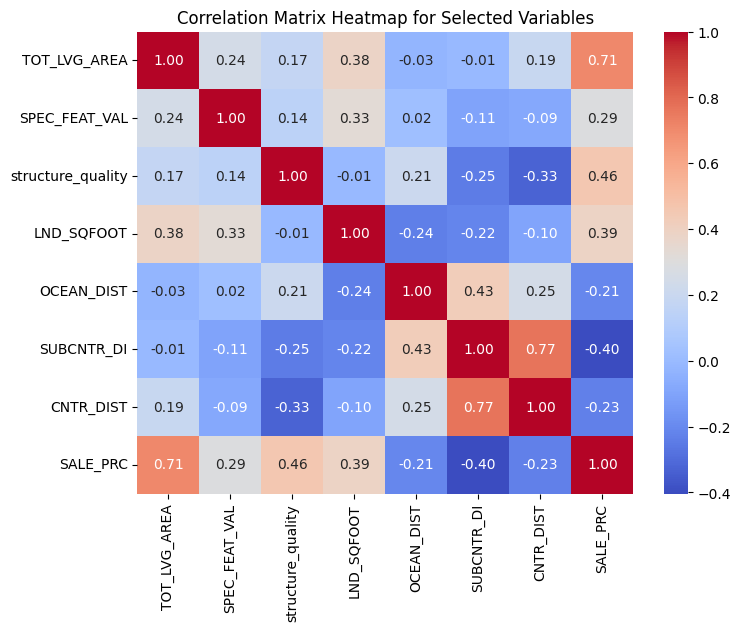

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
miami_housing_data = pd.read_csv('miami-housing.csv')
# Apply log transformation to highly skewed variables (adding 1 to avoid log(0) issues)
transformed_data = miami_housing_data.copy()
highly_skewed_vars = ["avno60plus", "LND_SQFOOT", "SALE_PRC", "SPEC_FEAT_VAL", "TOT_LVG_AREA"]

for var in highly_skewed_vars:
    transformed_data[var] = np.log1p(transformed_data[var])

# Subset the data for the specified variables
selected_variables = [
    "TOT_LVG_AREA",
    "SPEC_FEAT_VAL",
    "structure_quality",
    "LND_SQFOOT",
    "OCEAN_DIST",
    "SUBCNTR_DI",
    "CNTR_DIST",
    "SALE_PRC"
]

selected_data = transformed_data[selected_variables]

# Calculate the correlation matrix for the selected variables
selected_correlation_matrix = selected_data.corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(selected_correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix Heatmap for Selected Variables")
plt.show()



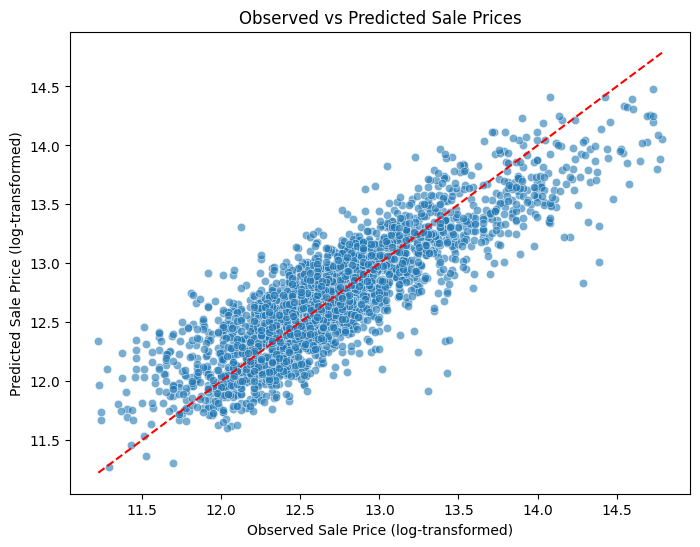

Root Mean Square Error (RMSE): 0.2917291789422466


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


miami_housing_data = pd.read_csv('miami-housing.csv')

# Apply log transformation to highly skewed variables (adding 1 to avoid log(0) issues)
transformed_data = miami_housing_data.copy()
highly_skewed_vars = ["avno60plus", "LND_SQFOOT", "SALE_PRC", "SPEC_FEAT_VAL", "TOT_LVG_AREA"]

for var in highly_skewed_vars:
    transformed_data[var] = np.log1p(transformed_data[var])

# Include SALE_PRC in the selected_data DataFrame
selected_data = transformed_data[
    [
        "TOT_LVG_AREA",
        "SPEC_FEAT_VAL",
        "structure_quality",
        "LND_SQFOOT",
        "OCEAN_DIST",
        "SUBCNTR_DI",
        "CNTR_DIST",
        "SALE_PRC",
    ]
]

# Split the data into predictors (X) and target (y)
X = selected_data.drop(columns=["SALE_PRC"])
y = selected_data["SALE_PRC"]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Plot observed vs. predicted
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.title("Observed vs Predicted Sale Prices")
plt.xlabel("Observed Sale Price (log-transformed)")
plt.ylabel("Predicted Sale Price (log-transformed)")
plt.show()

# Calculating RMSE
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"Root Mean Square Error (RMSE): {rmse}")


In [ ]:
# Calculate the R-squared value for the original linear regression model
r_squared = model.score(X_test, y_test)
print(f"R-squared for the model: {r_squared}")


R-squared for the model: 0.7356222857907495


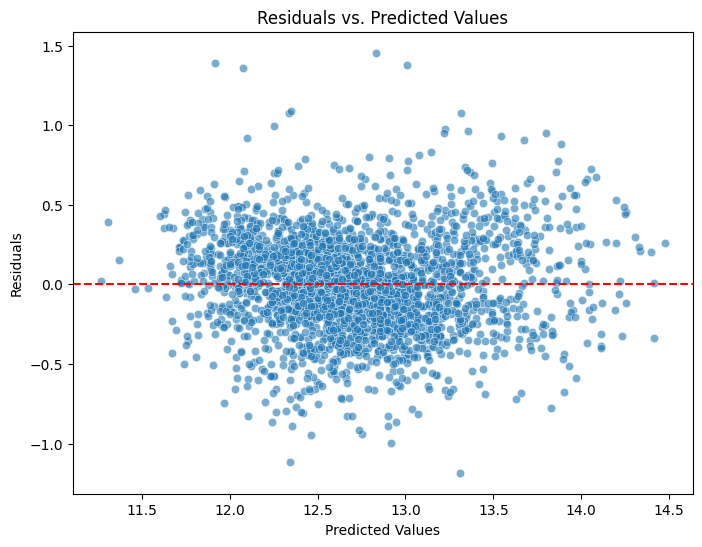

In [ ]:
#Linearity test
# Calculate residuals
residuals = y_test - y_pred

# Plot residuals vs. predicted values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.title("Residuals vs. Predicted Values")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()


In [ ]:
from statsmodels.stats.stattools import durbin_watson

# Durbin-Watson test
dw_stat = durbin_watson(residuals)
print(f"Durbin-Watson Statistic: {dw_stat}")


Durbin-Watson Statistic: 1.9865977136329902


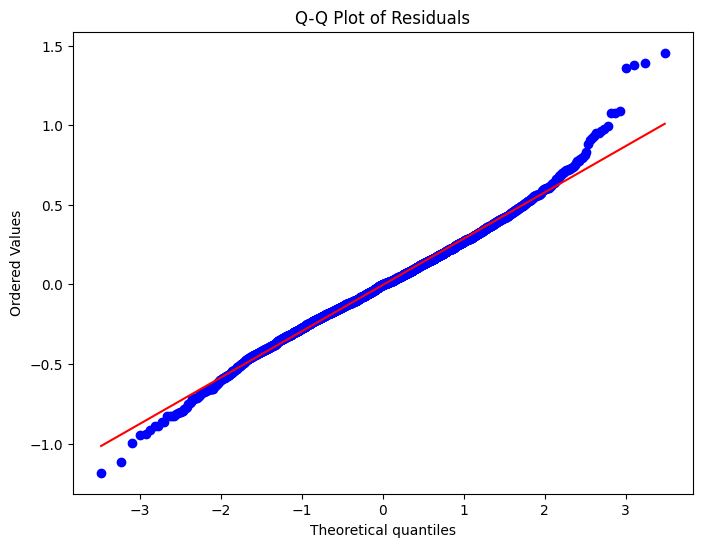

Shapiro-Wilk Test Statistic: 0.9912636790676598, p-value: 5.482827059156028e-12


In [ ]:
#normality of residuals
from scipy.stats import probplot, shapiro

# Q-Q plot
plt.figure(figsize=(8, 6))
probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

# Shapiro-Wilk test for normality
shapiro_test_stat, shapiro_p_value = shapiro(residuals)
print(f"Shapiro-Wilk Test Statistic: {shapiro_test_stat}, p-value: {shapiro_p_value}")


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Generate interaction terms and polynomial features
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
X_poly = poly.fit_transform(X)


feature_names = poly.get_feature_names_out(X.columns)


X_poly_df = pd.DataFrame(X_poly, columns=feature_names)

#Combine the polynomial features with the target variable
X_poly_df["SALE_PRC"] = y.reset_index(drop=True)

# Split the data again with the new features
X_poly_features = X_poly_df.drop(columns=["SALE_PRC"])
y_poly = X_poly_df["SALE_PRC"]
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(
    X_poly_features, y_poly, test_size=0.2, random_state=42
)

#Retrain the linear regression model with the polynomial features
model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train_poly)

# Predict and calculate R-squared and RMSE with polynomial features
y_pred_poly = model_poly.predict(X_test_poly)
r_squared_poly = model_poly.score(X_test_poly, y_test_poly)
rmse_poly = mean_squared_error(y_test_poly, y_pred_poly, squared=False)

# Display the performance metrics
print(f"R-squared with polynomial features: {r_squared_poly}")
print(f"RMSE with polynomial features: {rmse_poly}")


R-squared with polynomial features: 0.8363167614463947
RMSE with polynomial features: 0.22954590661993174


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures

# Assume that 'model_poly' is your trained model with polynomial features
# and 'poly' is the PolynomialFeatures transformer used during training.

# Step 1: Define scenarios as a DataFrame
scenario_data = pd.DataFrame({
    "TOT_LVG_AREA": [np.log1p(4000), np.log1p(2000), np.log1p(1000)],  # Log-transformed
    "SPEC_FEAT_VAL": [np.log1p(50000), np.log1p(25000), np.log1p(10000)],
    "structure_quality": [8, 5, 3],
    "LND_SQFOOT": [np.log1p(8000), np.log1p(6000), np.log1p(4000)],
    "OCEAN_DIST": [np.log1p(0.5), np.log1p(2), np.log1p(5)],
    "SUBCNTR_DI": [np.log1p(1), np.log1p(3), np.log1p(6)],
    "CNTR_DIST": [np.log1p(2), np.log1p(5), np.log1p(10)]
})


# Step 2: Generate polynomial features for the scenario data
scenario_poly_features = poly.transform(scenario_data)

# Step 3: Predict using the trained polynomial regression model
predicted_sale_prices_log = model_poly.predict(scenario_poly_features)

# If you want to convert the log-transformed sale prices back to original scale
predicted_sale_prices = np.expm1(predicted_sale_prices_log)

# Combine the scenarios with their predictions
scenario_results = scenario_data.copy()
scenario_results["Predicted_Sale_Price"] = predicted_sale_prices

# Display the results
print("Scenario Testing Results:")
print(scenario_results)


Scenario Testing Results:
   TOT_LVG_AREA  SPEC_FEAT_VAL  structure_quality  LND_SQFOOT  OCEAN_DIST  \
0      8.294300      10.819798                  8    8.987322    0.405465   
1      7.601402      10.126671                  5    8.699681    1.098612   
2      6.908755       9.210440                  3    8.294300    1.791759   

   SUBCNTR_DI  CNTR_DIST  Predicted_Sale_Price  
0    0.693147   1.098612          1.015422e+07  
1    1.386294   1.791759          1.278906e+06  
2    1.945910   2.397895          3.562308e+05  


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd

# Define a DataFrame with your scenario testing results
scenario_results = pd.DataFrame({
    "TOT_LVG_AREA": [8.294300, 7.601402, 6.908755],
    "SPEC_FEAT_VAL": [10.819798, 10.126671, 9.210440],
    "structure_quality": [8, 5, 3],
    "LND_SQFOOT": [8.987322, 8.699681, 8.294300],
    "OCEAN_DIST": [0.405465, 1.098612, 1.791759],
    "SUBCNTR_DI": [0.693147, 1.386294, 1.945910],
    "CNTR_DIST": [1.098612, 1.791759, 2.397895],
    "Predicted_Sale_Price": [1.015422e+07, 1.278906e+06, 3.562308e+05]
})

# Format the numbers for better readability
scenario_results_formatted = scenario_results.copy()
scenario_results_formatted["Predicted_Sale_Price"] = scenario_results_formatted["Predicted_Sale_Price"].apply(
    lambda x: "{:,.2f}".format(x)
)

# Print the DataFrame in the desired format
print("Scenario Testing Results:")
print(scenario_results_formatted.to_string(index=False))


Scenario Testing Results:
 TOT_LVG_AREA  SPEC_FEAT_VAL  structure_quality  LND_SQFOOT  OCEAN_DIST  SUBCNTR_DI  CNTR_DIST Predicted_Sale_Price
     8.294300      10.819798                  8    8.987322    0.405465    0.693147   1.098612        10,154,220.00
     7.601402      10.126671                  5    8.699681    1.098612    1.386294   1.791759         1,278,906.00
     6.908755       9.210440                  3    8.294300    1.791759    1.945910   2.397895           356,230.80
